# **Food Delivery Time Prediction using Exploratory Data Analysis (EDA)**


**Final Project**

**Ajul Krishna KV**

**DA30**

----
-----

**Introducion**

With the increasing demand for online food delivery services, accurately predicting delivery time has become essential for improving customer satisfaction and operational efficiency. This project focuses on analyzing a large dataset of food delivery records in India to identify key factors affecting delivery time and to derive meaningful insights.

The dataset used in this project contains food delivery records including order details, delivery partner information, and external factors such as traffic and weather conditions.

Data source : https://www.kaggle.com/datasets/changlechangsu/india-food-delivery-time-prediction

**Problem Statement**

The main objective of this project is to analyze the dataset and understand the factors influencing delivery time. By performing data cleaning, feature engineering, and exploratory data analysis, the goal is to prepare the data for building predictive models and improving delivery efficiency.

**objectives**

* To perform Exploratory Data Analysis (EDA) on food delivery data
* To clean and preprocess raw, unstructured data
* To identify key factors influencing delivery time
* To prepare the dataset for predictive modeling
* To derive actionable insights for delivery optimization

------

 **Data Loading and Initial Overview**


In [1]:
# Step 1: Upload file manually
from google.colab import files
uploaded = files.upload()

Saving India-Food-Delivery-Time-Prediction.txt to India-Food-Delivery-Time-Prediction.txt


Importing Libraries and Initial Setup

At the beginning of the analysis, essential Python libraries were imported to facilitate data handling, computation, and visualization.

* Pandas (pd) was used for data manipulation and analysis, allowing efficient handling of structured datasets through DataFrames.
* NumPy (np) was utilized for numerical operations and mathematical computations, providing support for arrays and advanced calculations.
* Matplotlib (plt) served as the core visualization library for creating basic plots and customizing graphical outputs.
* Seaborn (sns) was used for advanced statistical visualizations, offering more aesthetically pleasing and informative plots compared to Matplotlib.

In [4]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


In [5]:
# Loading dataset
df = pd.read_json("India-Food-Delivery-Time-Prediction.txt")
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:33:33,11:45:29,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:37,19:51:49,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,8:32:58,8:48:47,conditions Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:03:58,18:12:52,conditions Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:34:16,13:45:36,conditions Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,(min) 30


In [ ]:
df.shape

(41953, 20)

Dataset contains 41953 rows and 20 columns

In [6]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [7]:
# Data type of each columns are given below
df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  object 
 1   Delivery_person_ID           41953 non-null  object 
 2   Delivery_person_Age          40234 non-null  float64
 3   Delivery_person_Ratings      40190 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  object 
 9   Time_Orderd                  40353 non-null  object 
 10  Time_Order_picked            41953 non-null  object 
 11  Weatherconditions            41953 non-null  object 
 12  Road_traffic_density         41953 non-null  object 
 13  Vehicle_conditio

In [8]:
# statistical summary of numerical columns

df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries
count,40234.000000,40190.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41048.000000
mean,29.563330,4.632386,18.911397,76.923408,18.975064,76.987074,1.022716,0.745249
std,5.812361,0.335541,5.467829,3.502910,5.469616,3.503073,0.838893,0.572152
min,15.000000,1.000000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000
25%,25.000000,4.500000,12.986047,73.898520,13.065996,73.940327,0.000000,0.000000
50%,30.000000,4.700000,19.065838,76.618203,19.123249,76.663622,1.000000,1.000000
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,2.000000,1.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000


 **Dataset Overview**

The dataset used in this project contains 41,953 records and 20 columns, representing food delivery operations in India. It includes information related to delivery personnel, order details, location coordinates, and delivery performance.

Data Structure
* Total Rows: 41,953
* Total Columns: 20
* Data Types:

    - Numerical columns: 7
   - Categorical columns: 12
    - Integer columns: 1

The dataset includes the following important features:

Delivery_person_Age & Delivery_person_Ratings -
Provide information about delivery personnel characteristics.

Restaurant & Delivery Location Coordinates -
Latitude and longitude values used to calculate delivery distance.

Order_Date, Time_Orderd, Time_Order_picked -
Time-related features used for temporal analysis and feature engineering.

Weatherconditions & Road_traffic_density -
External factors affecting delivery time.

Type_of_order & Type_of_vehicle -
Provide contextual information about delivery operations.

multiple_deliveries -
Indicates workload on delivery personnel.

Time_taken(min) -
Target variable representing delivery duration.

The primary objective of this dataset is to **analyze and predict delivery time** based on various operational, environmental, and personnel-related factors. This helps in improving delivery efficiency and providing accurate time estimates to customers.


-------

**Data Pre-processing**

Missing Values Analysis

To ensure data quality, a missing value analysis was performed using
df.isnull().sum()

In [9]:
# Check missing values

df.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,1719
Delivery_person_Ratings,1763
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1600


Missing value analysis showed that Delivery_person_Age (1719), Delivery_person_Ratings (1769), Time_Orderd (1600), and multiple_deliveries (905) contain missing values. These were handled using appropriate techniques such as median imputation and data preprocessing to ensure better analysis.


Proper handling of missing values improved data quality and ensured that the dataset was suitable for further exploratory analysis and predictive modeling.

Numerical columns such as Delivery_person_Age, Delivery_person_Ratings, and multiple_deliveries were treated using median imputation, as it is less affected by outliers. The Time_Orderd column, being a time-based feature, was handled carefully during preprocessing to avoid inconsistencies.

Convert Columns Properly

The dataset contained string values like ‘NaN’ and extra spaces, so they were cleaned by stripping spaces and converting string NaN values into actual missing values for proper preprocessing

In [10]:
# Remove spaces
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Replace string 'NaN' with actual NaN
df.replace("NaN", np.nan, inplace=True)

/tmp/ipykernel_4911/884879703.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


Convert data types

The columns were converted from string to numeric using pd.to_numeric to enable mathematical operations, and errors='coerce' was used to handle invalid values by converting them into missing values

In [11]:
df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'], errors='coerce')
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce')
df['multiple_deliveries'] = pd.to_numeric(df['multiple_deliveries'], errors='coerce')

**Handle missing values**

Missing values in numerical columns were handled using median imputation to reduce the effect of outliers and maintain data consistency.

Median was used because columns like Delivery_person_Age, Delivery_person_Ratings, and multiple_deliveries may contain outliers and uneven distributions. Using median ensures that these extreme values do not distort the data while filling missing values.

In [12]:
df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median(), inplace=True)
df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median(), inplace=True)
df['multiple_deliveries'].fillna(df['multiple_deliveries'].median(), inplace=True)

/tmp/ipykernel_4911/2810938890.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median(), inplace=True)
/tmp/ipykernel_4911/2810938890.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

Time-related columns were converted into datetime format to enable time-based calculations like preparation time and ensure consistency in analysis.
function used here is pd.to_datetime().Also used errors='coerce'for converting Invalid or incorrectly formatted values to NaT (Not a Time) instead of causing errors

In [13]:
# Convert to datetime
df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], errors='coerce')

/tmp/ipykernel_4911/813689778.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], errors='coerce')


The Time_Orderd column had 1600 missing values. Since time-based features cannot be reliably imputed without introducing bias, the corresponding rows were removed.Comparing large dataset size, this had minimal impact on the overall analysis

In [14]:
df = df.dropna(subset=['Time_Orderd'])

Categorical columns are Filling with "Unknown"

All categorical columns were identified and their missing values were replaced with ‘Unknown’ to maintain data consistency

In [15]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna("Unknown", inplace=True)

/tmp/ipykernel_4911/2111845635.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna("Unknown", inplace=True)


In [16]:
df.isnull().sum()  # for verifying

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0


Post-Cleaning Verification
After performing data cleaning, a recheck was conducted:

Result:
All columns now contain 0 missing values

Dataset is fully cleaned and ready for analysis

**Missing values were identified and handled using appropriate imputation techniques, and the dataset was verified to be completely clean before analysis**

Impact of Data Cleaning
* Improved data quality and consistency
* Prevented errors during analysis and modeling
* Ensured accurate insights and predictions
* Allowed use of the entire dataset without dropping records

**Removing duplicates**

To ensure data quality and avoid redundancy, duplicate records in the dataset were checked using:

df.duplicated().sum()

In [17]:
df.duplicated().sum()

np.int64(0)

Duplicate analysis was performed using df.duplicated().sum(), and no duplicate records were identified in the dataset.

ie . Each row represents a unique observation

----

**Creating derived columns**

To enhance the quality of analysis and extract deeper insights, new features (derived columns) were created from the existing dataset.
Derived columns help in transforming raw data into more meaningful and useful information for analysis and modeling. The original data may not directly provide all the insights required for analysis, so new features are generated by transforming or combining existing variables.

Purpose of Creating Derived Columns
* To improve data interpretability
* To uncover hidden patterns and relationships
* To make the dataset more suitable for analysis and prediction models
* To simplify complex raw data into usable features


1.**Preparation Time**

This feature represents the time taken by the restaurant to prepare the order after it is placed.

It is calculated as the difference between order placed time and order picked time

Helps in analyzing:
* Restaurant efficiency
* Delay before delivery starts

In [18]:
# Preparation Time
# Time taken from order placed → order picked

df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], errors='coerce')
df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], errors='coerce')
df['Preparation_Time'] = (df['Time_Order_picked'] - df['Time_Orderd']).dt.total_seconds() / 60


/tmp/ipykernel_4911/3013109535.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], errors='coerce')


2.**Day of the Week**

This feature extracts the day (e.g., Monday, Tuesday) from the order date.

Helps identify:
* Weekly order patterns
* Busy vs slow days

Useful for understanding demand variation across days

In [19]:
# Day of Week
# Extracts day like Monday, Tuesday from date

df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Day'] = df['Order_Date'].dt.day_name()

3.**Distance (Distance_km)**

This feature calculates the distance between the restaurant and delivery location using geographical coordinates.

Computed using:
* Latitude and Longitude values

Helps in:
* Measuring delivery effort
* Analyzing impact of distance on delivery time

Delivery distance was calculated using the **geodesic method** from the **geopy library**, which computes the shortest distance between two geographical coordinates. geopy is a Python library used for working with geographical data, especially for calculating distances between locations using latitude and longitude.This feature plays a key role in understanding delivery time variations.

In [21]:
# Distance

!pip install geopy

In [22]:
from geopy.distance import geodesic

def calculate_distance(row):
    point1 = (row['Restaurant_latitude'], row['Restaurant_longitude'])
    point2 = (row['Delivery_location_latitude'], row['Delivery_location_longitude'])
    return geodesic(point1, point2).km

df['Distance_km'] = df.apply(calculate_distance, axis=1)

4.**Order Hour**

This feature extracts the hour at which the order was placed.

Helps identify:
* Peak hours (lunch/dinner time)
* Off-peak periods

Useful for analyzing time-based delivery trends

In [23]:
# Order Hour
df['Order_Hour'] = df['Time_Orderd'].dt.hour

**Derived Features**

Derived features were created to transform raw data into more meaningful variables that better capture operational patterns and improve the effectiveness of analysis. To enhance the dataset and extract meaningful insights, following features were derived from the existing columns.

**Preparation_Time:**

Calculated as the difference between Time_Order_picked and Time_Orderd. This represents the time taken by the restaurant to prepare the order and is an important factor influencing overall delivery time.This feature helps identify delays originating from the restaurant side and enables separation of preparation delays from delivery delays.

**Day:**

Extracted from the Order_Date column to identify patterns based on the day of the week. This helps in analyzing variations in delivery performance across different days.It also helps in identifying peak demand days (eg. weekends), which may impact delivery performance due to higher order volumes.

**Distance_km:**

Computed using the geographical coordinates of the restaurant and delivery location. This feature represents the delivery distance and plays a key role in determining delivery time.This feature is critical for analyzing delivery efficiency and is expected to have a strong positive correlation with delivery time.

Delivery distance was calculated using the **geodesic method** from the **geopy library**, which computes the shortest distance between two geographical coordinates. geopy is a Python library used for working with geographical data, especially for calculating distances between locations using latitude and longitude.This feature plays a key role in understanding delivery time variations.

**Order_Hour**:

Derived from the order time to understand peak ordering hours and their impact on delivery efficiency.This enables identification of peak ordering periods such as lunch and dinner hours, which may lead to increased delivery times due to higher demand.

Overall, these derived features play a crucial role in uncovering hidden patterns within the dataset. They enable a deeper understanding of factors affecting delivery time, including operational delays, distance-related constraints, and temporal demand variations.These features were further used for visualization and analysis to identify key drivers of delivery performance.

In [24]:
df[['Preparation_Time', 'Day', 'Distance_km', 'Order_Hour']].head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 40353 entries, 0 to 41952
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           40353 non-null  object        
 1   Delivery_person_ID           40353 non-null  object        
 2   Delivery_person_Age          40353 non-null  float64       
 3   Delivery_person_Ratings      40353 non-null  float64       
 4   Restaurant_latitude          40353 non-null  float64       
 5   Restaurant_longitude         40353 non-null  float64       
 6   Delivery_location_latitude   40353 non-null  float64       
 7   Delivery_location_longitude  40353 non-null  float64       
 8   Order_Date                   40353 non-null  datetime64[ns]
 9   Time_Orderd                  40353 non-null  datetime64[ns]
 10  Time_Order_picked            40353 non-null  datetime64[ns]
 11  Weatherconditions            40353 non-null  o

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Vehicle_condition,multiple_deliveries,Preparation_Time,Distance_km,Order_Hour
count,40353.000000,40353.000000,40353.000000,40353.000000,40353.000000,40353.000000,40353,40353,40353,40353.000000,40353.000000,40353.000000,40353.000000,40353.000000
mean,29.554829,4.634387,18.911836,76.918480,18.975471,76.982116,2022-03-14 04:52:45.623373824,2026-04-04 17:56:12.848660480,2026-04-04 17:40:10.596882688,0.999876,0.750031,-16.037530,9.699451,17.403018
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,2022-02-11 00:00:00,2026-04-04 00:00:00,2026-04-04 00:00:02,0.000000,0.000000,-1439.500000,1.463837,0.000000
25%,25.000000,4.500000,12.986047,73.897902,13.065996,73.940327,2022-03-05 00:00:00,2026-04-04 15:24:01,2026-04-04 14:37:43,0.000000,0.000000,5.516667,4.648474,15.000000
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.662278,2022-03-15 00:00:00,2026-04-04 19:16:32,2026-04-04 19:12:15,1.000000,1.000000,9.283333,9.177288,19.000000
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.403391,2022-03-27 00:00:00,2026-04-04 21:37:23,2026-04-04 21:37:13,2.000000,1.000000,13.133333,13.611208,21.000000
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2022-04-06 00:00:00,2026-04-04 23:59:57,2026-04-04 23:59:57,2.000000,3.000000,19.883333,20.942906,23.000000
std,5.746713,0.313975,5.468296,3.500531,5.470105,3.500743,NaN,NaN,NaN,0.816218,0.567368,189.788237,5.588504,4.848602


**Filtering data**

Filtering is used to select specific subsets of data based on certain conditions. It helps in focusing on particular scenarios within the dataset, making analysis more targeted and meaningful. It
* Helps focus on relevant data
* Enables analysis of specific scenarios
* Makes it easier to identify patterns and trends
* Supports better decision-making

In this project, filtering was applied to analyze specific conditions such as high traffic, long delivery times, and peak hours. This allowed a deeper understanding of how different factors impact delivery performance.

1 . High Traffic Deliveries Analysis

To understand the impact of traffic congestion on delivery performance, the dataset was filtered to include only records where road traffic density was classified as “High.”
This subset of data was used to specifically analyze how heavy traffic conditions influence delivery time and overall efficiency.

In [25]:
# High traffic deliveries

high_traffic = df[df['Road_traffic_density'] == 'High']

# Helps analyze delay due to traffic

Observations
* Deliveries under high traffic conditions tend to experience longer delivery times
* Increased congestion leads to delays in transit, even for moderate distances
* Variability in delivery time is higher under heavy traffic

2 .Long Deliveries Analysis (>40 Minutes)

To identify delayed deliveries, the dataset was analyzed by filtering records where the delivery time exceeded 40 minutes. This threshold was used to classify deliveries as long or delayed.

In [26]:
# Long deliveries (>40 mins)

df['Time_taken(min)'] = df['Time_taken(min)'].str.replace('(min) ', '')
df['Time_taken(min)'] = pd.to_numeric(df['Time_taken(min)'], errors='coerce')        # Converting column to numeric from string value.
long_delivery = df[df['Time_taken(min)'] > 40]

# Helps identify slow deliveries

The delivery time column was first cleaned and converted into numeric format. Then, deliveries taking more than 40 minutes were filtered to identify delayed orders.

Observations

* A portion of deliveries exceeds the 40-minute threshold, indicating performance inefficiencies
* Long delivery times are often associated with:
  * High traffic conditions
  * Longer distances
  * Peak order hours

Weekend Orders Analysis

To understand order patterns during peak days, the dataset was filtered to include only records from weekends (Saturday and Sunday). This subset was used to analyze how delivery behavior changes during high-demand periods.

In [27]:
# Weekend orders

weekend = df[df['Day'].isin(['Saturday', 'Sunday'])]

# Helps study peak days

Data was filtered for orders placed on weekends (Saturday and Sunday) to analyze peak-day behavior.

Observations

* Weekends tend to have higher order volumes compared to weekdays
* Delivery times may be slightly higher due to:
  * Increased demand
  * Higher traffic congestion
* Operational load is typically greater during weekends

Filtering was applied to extract specific subsets of data based on conditions such as traffic density, delivery time, and day of the week. This helped in analyzing particular scenarios and understanding how different factors influence delivery performance.

------

**Aggregating Data**

Data aggregation is the process of summarizing and grouping data to extract meaningful insights. It involves combining multiple records into a single value using statistical functions such as mean, sum, count, minimum, and maximum.

In this project, aggregation was performed to analyze how different factors affect delivery time by grouping data based on specific features.

1. Multiple Deliveries on Delivery Time

In [28]:
# Distance impact

df.groupby('multiple_deliveries')['Time_taken(min)'].mean()

,Time_taken(min)
multiple_deliveries,
0.0,22.890143
1.0,26.736187
2.0,40.425365
3.0,47.858065


Impact of Multiple Deliveries on Delivery Time

The dataset was analyzed to understand how the number of deliveries assigned to a delivery agent affects the overall delivery time. A grouping operation was performed on the variable multiple_deliveries, and the average Time_taken (min) was calculated for each category.

The results indicate a strong positive relationship between the number of deliveries and the time taken.

Insights
* There is a clear upward trend, showing that delivery time increases as the number of deliveries handled simultaneously increases.

* The jump from 1 to 2 deliveries shows a particularly sharp increase, suggesting possible inefficiencies or route complexity beyond a certain load.

* Assigning too many deliveries to a single agent may negatively impact service efficiency and customer satisfaction.

2. Traffic Density on Delivery Time

In [29]:
# Traffic vs Avg Delivery Time

df.groupby('Road_traffic_density')['Time_taken(min)'].mean()

,Time_taken(min)
Road_traffic_density,
High,27.194214
Jam,31.157080
Low,21.287999
Medium,26.746340


Impact of Road Traffic Density on Delivery Time

To evaluate how traffic conditions influence delivery performance, the dataset was grouped based on Road_traffic_density, and the average Time_taken (min) was calculated for each traffic category.

Insights
* There is a clear increasing trend in delivery time as traffic density worsens.
* The difference between Low and Jam traffic is nearly 10 minutes, highlighting the significant impact of congestion.
* Even the transition from Medium to High traffic shows a noticeable delay, indicating that moderate congestion already affects efficiency.

3. Weather Conditions on Delivery Time

In [30]:
# Weather vs Avg Delivery Time

df.groupby('Weatherconditions')['Time_taken(min)'].mean()

,Time_taken(min)
Weatherconditions,
conditions Cloudy,28.945754
conditions Fog,28.990358
conditions Sandstorms,25.902933
conditions Stormy,25.878783
conditions Sunny,21.882828
conditions Windy,26.115356


Impact of Weather Conditions on Delivery Time

To understand the effect of weather on delivery efficiency, the dataset was grouped based on Weatherconditions, and the average Time_taken (min) was computed for each weather category.

Insights
* Weather conditions significantly influence delivery time, with clear weather (Sunny) enabling the fastest deliveries.
* Fog and Cloudy conditions cause the most delays, likely due to reduced visibility and cautious driving.
* Interestingly, Stormy and Sandstorm conditions show slightly lower delivery times than Fog, which may indicate adaptive behavior such as route adjustments or reduced delivery volume during extreme weather.
* There is a noticeable gap of about 7 minutes between Sunny and Fog conditions, highlighting the operational impact of adverse weather.

4. City Type on Delivery Time

In [31]:
# City vs Avg Delivery Time

df.groupby('City')['Time_taken(min)'].mean()

,Time_taken(min)
City,
Metropolitian,27.317670
Semi-Urban,49.680851
Unknown,22.117092
Urban,23.041196


Impact of City Type on Delivery Time

To analyze how the type of city affects delivery performance, the dataset was grouped based on City, and the average Time_taken (min) was calculated for each category.

Insights
* Delivery times tend to increase as we move from Urban to Metropolitan areas, likely due to higher traffic density and congestion.
* The extremely high delivery time in Semi-Urban areas suggests possible challenges such as longer distances, limited infrastructure, or fewer delivery resources.
* The Unknown category having the lowest time may indicate missing or inconsistent data, and should be interpreted with caution.
* There is a substantial gap (over 25 minutes) between Semi-Urban and Urban areas, highlighting a major operational difference.

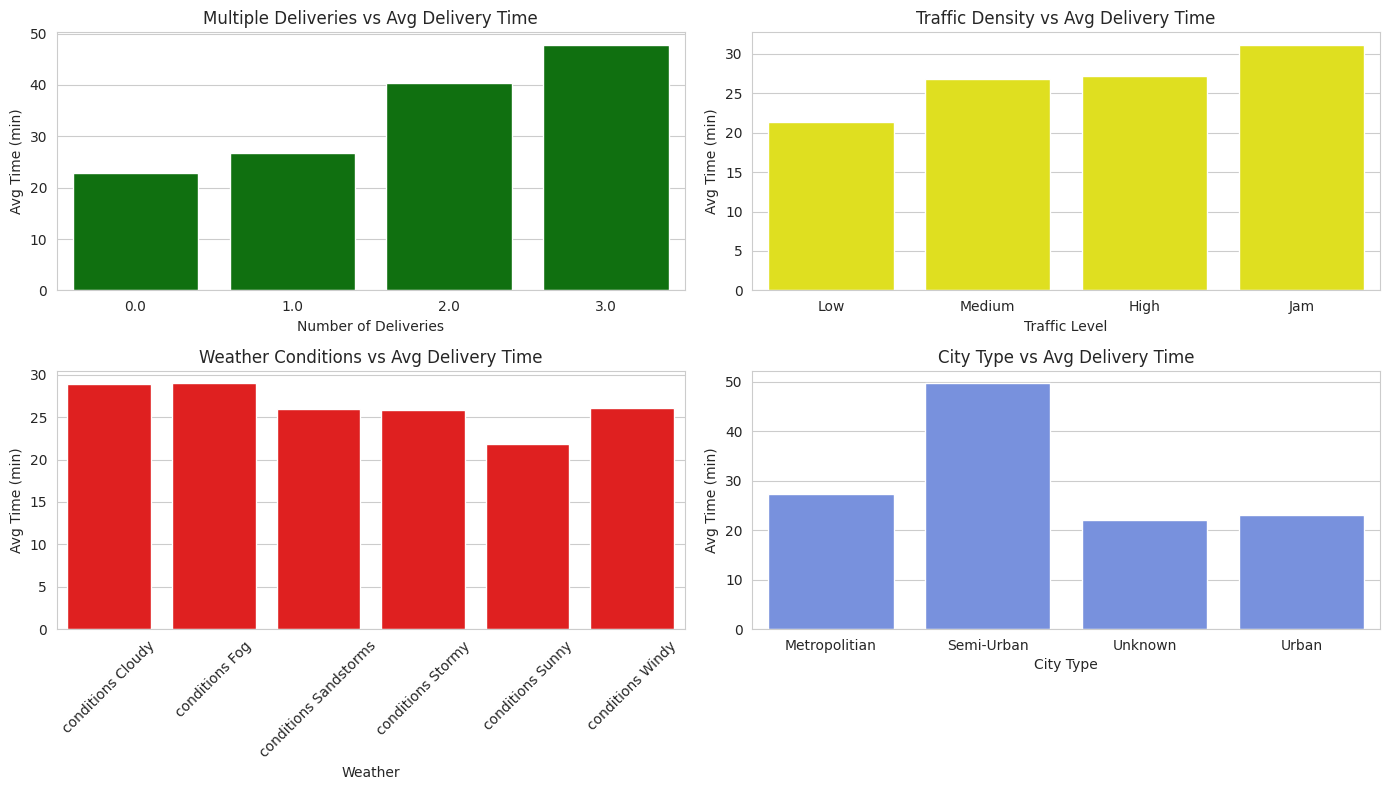

In [32]:
# Here used bar graphs because it is best suited for comparing values across different categories

sns.set_palette("coolwarm")
plt.figure(figsize=(14, 8))

# 1. Multiple Deliveries vs Time
plt.subplot(2, 2, 1)
md = df.groupby('multiple_deliveries')['Time_taken(min)'].mean().reset_index()
sns.barplot(data=md, x='multiple_deliveries', y='Time_taken(min)',color='green')
plt.title("Multiple Deliveries vs Avg Delivery Time")
plt.xlabel("Number of Deliveries")
plt.ylabel("Avg Time (min)")

# 2. Traffic vs Time
plt.subplot(2, 2, 2)
traffic = df.groupby('Road_traffic_density')['Time_taken(min)'].mean().reset_index()
sns.barplot(data=traffic, x='Road_traffic_density', y='Time_taken(min)',
            order=['Low','Medium','High','Jam'],color='yellow')
plt.title("Traffic Density vs Avg Delivery Time")
plt.xlabel("Traffic Level")
plt.ylabel("Avg Time (min)")

# 3. Weather vs Time
plt.subplot(2, 2, 3)
weather = df.groupby('Weatherconditions')['Time_taken(min)'].mean().reset_index()
sns.barplot(data=weather, x='Weatherconditions', y='Time_taken(min)',color='red')
plt.xticks(rotation=45)
plt.title("Weather Conditions vs Avg Delivery Time")
plt.xlabel("Weather")
plt.ylabel("Avg Time (min)")
df['Weatherconditions'] = df['Weatherconditions'].str.replace('conditions ', '')

# 4. City vs Time
plt.subplot(2, 2, 4)
city = df.groupby('City')['Time_taken(min)'].mean().reset_index()
sns.barplot(data=city, x='City', y='Time_taken(min)')
plt.title("City Type vs Avg Delivery Time")
plt.xlabel("City Type")
plt.ylabel("Avg Time (min)")

plt.tight_layout()
plt.show()

**Observations**

* This analysis highlights the importance of optimizing delivery allocation. Limiting the number of simultaneous deliveries per agent or improving route planning strategies could significantly reduce delivery times and enhance operational performance.

* Traffic density plays a critical role in determining delivery time. Efficient route planning, real-time traffic monitoring, and adaptive delivery scheduling can help mitigate delays caused by heavy traffic conditions. Reducing exposure to high-density traffic areas could significantly improve delivery performance and customer satisfaction

* Weather plays a crucial role in delivery performance. Adverse conditions such as fog and heavy cloud cover can significantly delay deliveries. Incorporating weather-based planning, such as dynamic routing and adjusted delivery schedules, can help improve efficiency and ensure better customer satisfaction.

* City type has a significant impact on delivery efficiency. While urban and metropolitan areas show moderate delivery times, semi-urban regions present major challenges. Improving logistics infrastructure, optimizing delivery routes, and allocating resources effectively in semi-urban areas could help reduce delivery delays and enhance overall performance.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40353 entries, 0 to 41952
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           40353 non-null  object        
 1   Delivery_person_ID           40353 non-null  object        
 2   Delivery_person_Age          40353 non-null  float64       
 3   Delivery_person_Ratings      40353 non-null  float64       
 4   Restaurant_latitude          40353 non-null  float64       
 5   Restaurant_longitude         40353 non-null  float64       
 6   Delivery_location_latitude   40353 non-null  float64       
 7   Delivery_location_longitude  40353 non-null  float64       
 8   Order_Date                   40353 non-null  datetime64[ns]
 9   Time_Orderd                  40353 non-null  datetime64[ns]
 10  Time_Order_picked            40353 non-null  datetime64[ns]
 11  Weatherconditions            40353 non-null  o

Aggregation was performed using groupby operations to summarize delivery performance across different categories. Average delivery time was calculated for factors such as traffic density, weather conditions, and city type to identify patterns and trends.

-----

**Exploratory Data Analysis (EDA)**

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and understanding the dataset using statistical methods and visualizations. It helps uncover patterns, detect anomalies, test assumptions, and identify relationships between variables.

Univariate Analysis

Univariate Analysis involves analyzing a single variable at a time to understand its distribution, central tendency, and spread. It is the simplest form of data analysis and helps in gaining initial insights into the dataset.

In this project, univariate analysis was conducted on two key variables to understand their individual distributions and characteristics.

1. Delivery Time (Time_taken)

The distribution of delivery time was analyzed to understand the variation, central tendency, and spread of delivery durations. This helped in identifying typical delivery ranges as well as extreme values.

2. Distribution of Orders by City

The city-wise distribution of orders was examined to understand how orders are spread across different locations. This analysis provided insights into which cities contribute the most to the total number of orders.

In [34]:
df['Time_taken(min)'].skew()

np.float64(0.47851982606385024)

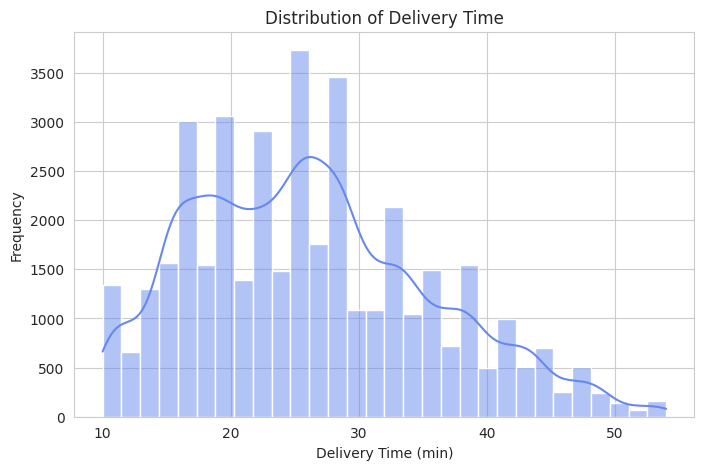

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df['Time_taken(min)'], bins=30, kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (min)")
plt.ylabel("Frequency")
plt.show()

Univariate Analysis – Delivery Time

To understand the overall distribution of delivery durations, a univariate analysis was performed on the variable Time_taken (min) using a histogram with a kernel density estimate (KDE).

Observations
* The distribution of delivery time appears to be slightly right-skewed, indicating that most deliveries are completed within a moderate time range, while a few take significantly longer.
* The majority of deliveries are concentrated roughly between 20 to 40 minutes, suggesting this is the typical delivery window.
* There is a noticeable peak (mode) around the mid-range values, indicating that most orders are delivered within this timeframe.
* The right tail of the distribution shows some higher delivery times, which may represent delays due to factors such as traffic congestion, longer distances, or adverse weather conditions.

Insights
* Delivery performance is generally consistent, with most deliveries falling within a predictable time range.
* The presence of a right tail suggests occasional delays, which could be investigated further using other variables like traffic, weather, or distance.
* The smooth KDE curve confirms that the data follows a near-normal but slightly skewed distribution.

The delivery time distribution indicates stable operational performance with most deliveries completed within an expected timeframe. However, the presence of outliers and longer delivery times highlights opportunities for optimization, particularly in handling exceptional conditions that cause delays.

Univariate Analysis - Distribution of Orders by City

In [36]:
city_dist = df['City'].value_counts().reset_index()
city_dist.columns = ['City', 'Count']

city_dist['Percentage'] = (city_dist['Count'] / city_dist['Count'].sum()) * 100

city_dist

,City,Count,Percentage
0,Metropolitian,30220,74.889104
1,Urban,8933,22.137140
2,Unknown,1059,2.624340
3,Semi-Urban,141,0.349416


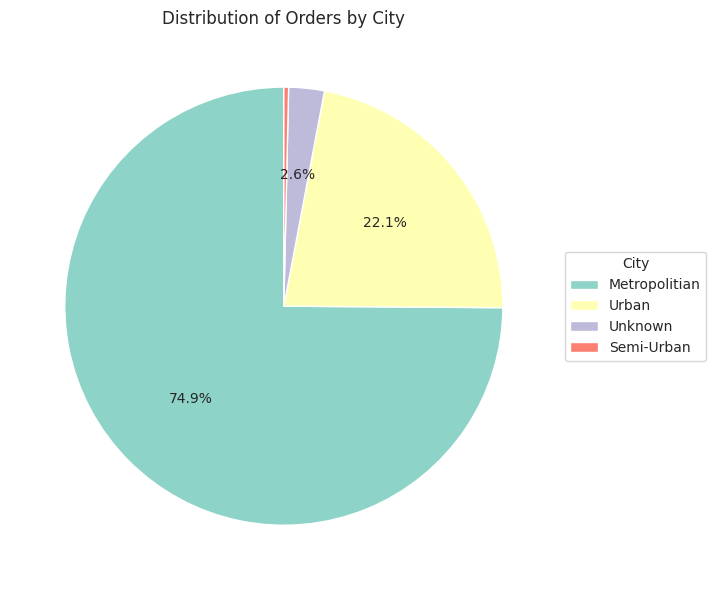

In [37]:
# Here using a pie chart to show the percentage distribution of categories and compare their contribution to the total.

plt.figure(figsize=(7,6))

counts = df['City'].value_counts()
labels = counts.index
sizes = counts.values

colors = plt.cm.Set3.colors

def autopct_format(pct):
    return f'{pct:.1f}%' if pct > 2 else ''       # show only if values > 2% . used here to overcome the overlap issues of % values

plt.pie(sizes,
    labels=None,
    autopct=autopct_format,
    colors=colors,
    startangle=90)

plt.title("Distribution of Orders by City")

plt.legend(
    labels,
    title="City",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

Univariate Analysis – Distribution of Orders by City

To understand how orders are distributed across different city types, a univariate analysis was performed on the City variable. A pie chart was used to visualize the proportion of orders in each category.

* The majority of orders come from Metropolitan cities, accounting for approximately 74.9% of the total.
* Urban areas contribute around 22.1% of the orders.
* Semi-Urban and Unknown categories represent a very small proportion (less than 5%).

Insights
* The dataset is highly skewed towards metropolitan cities, indicating that most delivery operations occur in densely populated areas.
* Lower representation from semi-urban areas suggests either lower demand or limited service availability.
* This imbalance may influence overall delivery performance metrics.
Conclusion

The distribution of orders shows a strong concentration in metropolitan regions, highlighting their importance in delivery operations. Future analysis and optimization strategies should prioritize metropolitan areas while also considering expansion opportunities in underrepresented regions.

Bivariate Analysis (Two Variables)

Bivariate analysis involves studying the relationship between two variables to understand how one variable influences another. It helps in identifying correlations, patterns, and dependencies within the dataset.

In this project, bivariate analysis was conducted to examine the impact of road traffic density on delivery time, in order to understand the relationship between these variables.

In [38]:
df.groupby('Road_traffic_density')['Time_taken(min)'].mean()

,Time_taken(min)
Road_traffic_density,
High,27.194214
Jam,31.157080
Low,21.287999
Medium,26.746340


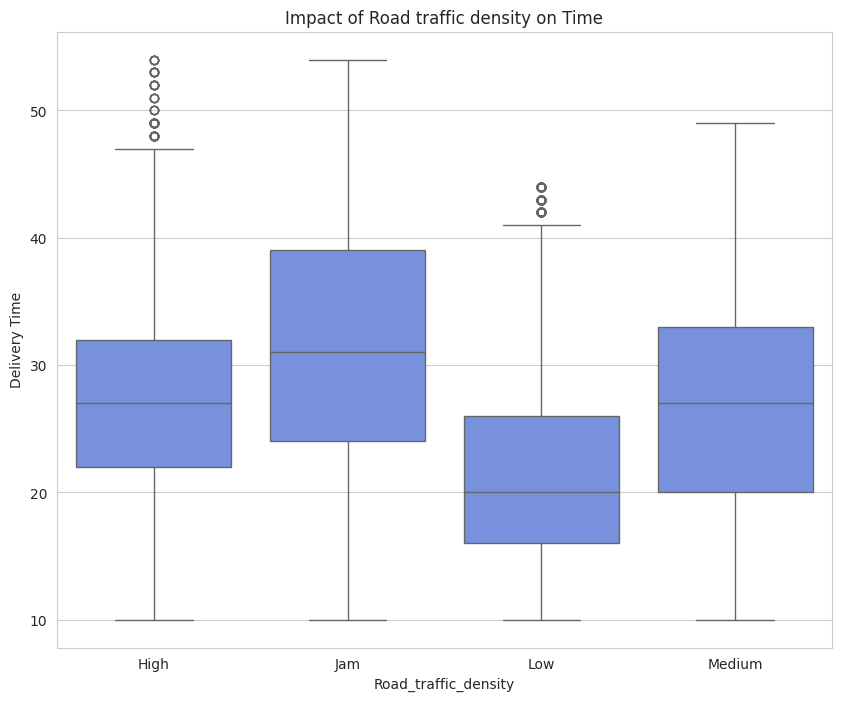

In [39]:
# Traffic vs Delivery Time
# here using box plot to understand the distribution of data and detect outliers across different categories

plt.figure(figsize=(10, 8))
sns.boxplot(x='Road_traffic_density', y='Time_taken(min)', data=df)
plt.title("Impact of Road traffic density on Time")
plt.xlabel("Road_traffic_density")
plt.ylabel("Delivery Time")
plt.show()

Bivariate Analysis – Impact of Road Traffic Density on Delivery Time

To examine the relationship between traffic conditions and delivery performance, a bivariate analysis was conducted using a boxplot comparing Road_traffic_density and Time_taken (min).

Observations
* The boxplot shows a clear variation in delivery time across different traffic conditions (Low, Medium, High, and Jam).
* Low traffic conditions have the lowest median delivery time and a relatively narrow spread, indicating consistent and faster deliveries.
* As traffic density increases to Medium and High, both the median delivery time and variability increase.
* Traffic Jam conditions exhibit the highest median delivery time along with a wider spread, indicating significant delays and inconsistency.
* There are several outliers observed, especially in higher traffic categories, representing unusually long delivery times.

Insights
* There is a positive relationship between traffic density and delivery time — higher congestion leads to longer delivery durations.
* Increased variability in higher traffic conditions suggests that delivery times become less predictable.
* The presence of outliers in all categories indicates that factors other than traffic (such as weather or distance) may also contribute to delays.

Traffic density has a significant impact on delivery efficiency. As congestion increases, both the delivery time and its variability rise. Effective traffic-aware routing strategies and dynamic delivery planning can help mitigate delays and improve consistency in delivery performance.

Multivariate Analysis

Multivariate analysis involves examining the relationship between more than two variables simultaneously to understand how multiple factors together influence a particular outcome. In this project, multivariate analysis was used to study how different features collectively affect delivery time.

Specifically, the analysis focused on the impact of distance and traffic density on delivery time, as well as the combined effect of order time, traffic conditions, and city. This helps in understanding how multiple real-world factors work together to influence delivery efficiency and delays.


Impact of Distance and Traffic Density on Delivery Time

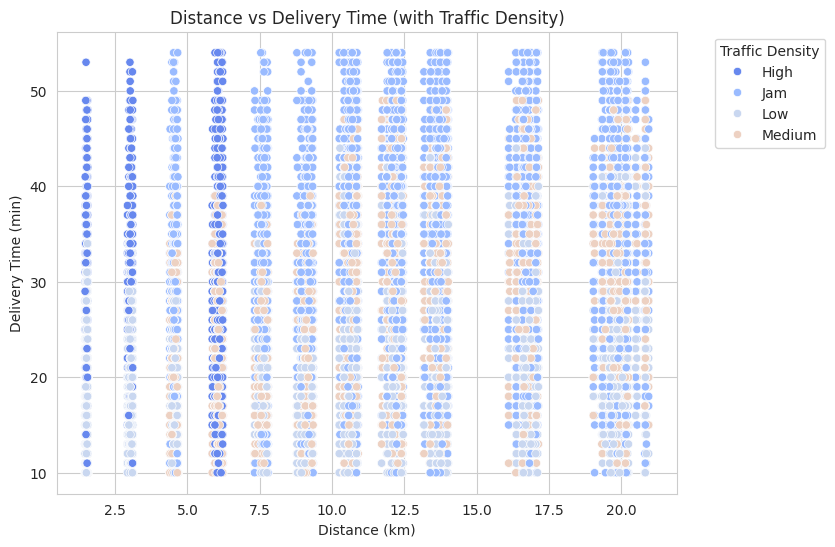

In [40]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,x='Distance_km',y='Time_taken(min)',
                hue='Road_traffic_density')

plt.title("Distance vs Delivery Time (with Traffic Density)")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.legend(title="Traffic Density", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Multivariate Analysis – Impact of Distance and Traffic Density on Delivery Time

To understand how multiple factors jointly influence delivery performance, a multivariate analysis was conducted using a scatter plot. The relationship between Distance_km and Time_taken (min) was analyzed, with Road_traffic_density represented using different colors.

* A clear positive relationship is observed between distance and delivery time, indicating that longer distances result in higher delivery durations.
* As distance increases, the spread of delivery time also increases, showing greater variability for longer routes.
* Traffic density significantly affects this relationship:
* Under low traffic conditions, delivery times are relatively lower across all distances.
* Under high traffic and jam conditions, delivery times are noticeably higher, especially for longer distances.
* The clustering of points shows that delivery time is influenced by both distance and traffic simultaneously.

Insights
* Distance is a primary factor affecting delivery time.
* Traffic density acts as a multiplying factor, increasing delays further, particularly for long-distance deliveries.
* The variability in delivery time suggests that other factors (such as weather or order volume) may also contribute.

This analysis demonstrates that delivery time is influenced by the combined effect of distance and traffic conditions. Efficient route planning and real-time traffic management can help minimize delays, especially for long-distance deliveries under heavy traffic conditions.

Multivariate Analysis (Multiple Variables)- Impact of Order Time, Traffic, and City on Delivery Time

In [41]:
multi_summary = df.groupby(
    ['Order_Hour', 'Road_traffic_density', 'City']
)['Time_taken(min)'].mean().reset_index()

multi_summary

,Order_Hour,Road_traffic_density,City,Time_taken(min)
0,0,Low,Metropolitian,23.136364
1,0,Low,Unknown,19.888889
2,0,Low,Urban,19.495726
3,8,Low,Metropolitian,20.371304
4,8,Low,Unknown,17.617021
...,...,...,...,...
68,22,Low,Unknown,20.510791
69,22,Low,Urban,20.237325
70,23,Low,Metropolitian,23.278639
71,23,Low,Unknown,19.250000


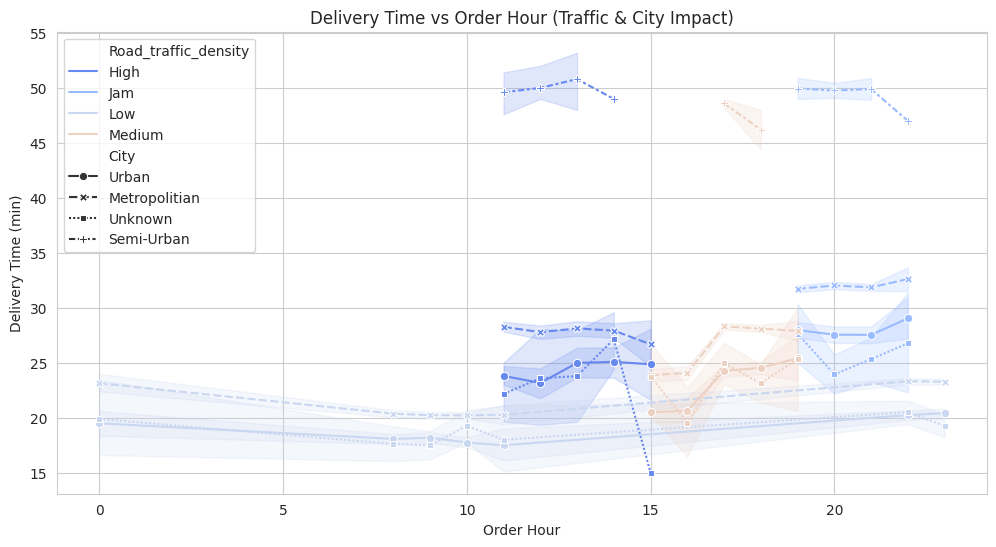

In [42]:
# Here using line plot to visualize trends and understand how values change across a continuous range

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x='Order_Hour',
    y='Time_taken(min)',
    hue='Road_traffic_density',
    style='City',
    markers=True
)

plt.title("Delivery Time vs Order Hour (Traffic & City Impact)")
plt.xlabel("Order Hour")
plt.ylabel("Delivery Time (min)")
plt.show()

Multivariate Analysis – Impact of Order Time, Traffic, and City on Delivery Time

A multivariate analysis was conducted to examine how order hour, traffic density, and city type collectively influence delivery time. A line plot was used where order hour is plotted against delivery time, with traffic density represented by color and city type represented by line style.

Observations
* Delivery time varies significantly across different hours of the day, indicating time-based demand patterns.
* During peak hours (typically lunch and dinner periods), delivery times tend to increase.
* Traffic density plays a major role, with higher traffic levels consistently resulting in longer delivery times across all hours.
* Differences across city types are also visible, with certain city categories showing higher delivery times during peak periods.

Insights
* Delivery performance is influenced by a combination of temporal, environmental, and geographical factors.
* Peak hours combined with high traffic conditions lead to the highest delivery delays.
* City type further modifies this relationship, indicating differences in infrastructure and traffic patterns.


This multivariate analysis highlights that delivery time is not dependent on a single factor but is influenced by multiple interacting variables such as order timing, traffic conditions, and city type. Understanding these combined effects can help improve delivery planning and resource allocation.

GroupBy Analysis

GroupBy analysis is used to explore and understand the relationship between different variables in the dataset by grouping similar data points together. It helps in summarizing large amounts of data and extracting meaningful insights.

In this project, GroupBy analysis is applied to examine how delivery time varies with factors such as delivery person ratings, weather conditions, and order hour. By calculating the average delivery time for each group, we can identify patterns and trends that influence delivery performance.

In [43]:
Ratings = df.groupby('Delivery_person_Ratings')['Time_taken(min)'].mean()

Weather = df.groupby('Weatherconditions')['Time_taken(min)'].mean()

Hour = df.groupby('Order_Hour')['Time_taken(min)'].mean()

display(Ratings.tail())
display(Weather.tail())
display(Hour.tail())

,Time_taken(min)
Delivery_person_Ratings,
4.6,24.611242
4.7,24.270821
4.8,24.035377
4.9,24.100804
5.0,25.521549


,Time_taken(min)
Weatherconditions,
Fog,28.990358
Sandstorms,25.902933
Stormy,25.878783
Sunny,21.882828
Windy,26.115356


,Time_taken(min)
Order_Hour,
19,30.746103
20,31.215289
21,31.082462
22,23.363333
23,22.439777


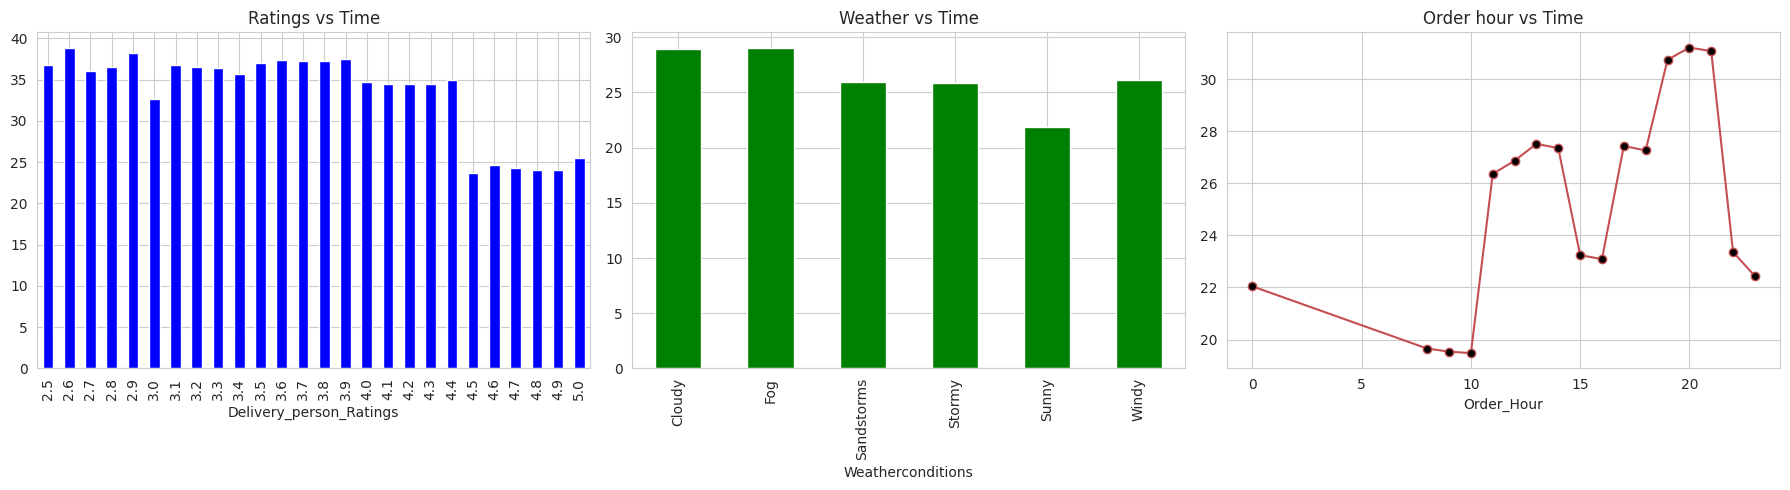

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

Ratings.plot(kind='bar', ax=axes[0], color='blue')
axes[0].set_title("Ratings vs Time")

Weather.plot(kind='bar', ax=axes[1], color='green')
Weather.index = Weather.index.str.replace('conditions ', '')
axes[1].set_title("Weather vs Time")

Hour.plot(kind='line',ax=axes[2],marker='o',color='#C44E52',
markerfacecolor='black')
axes[2].set_title("Order hour vs Time")

plt.tight_layout()
plt.show()

 GroupBy Analysis – Impact of Ratings, Weather, and Order Hour on Delivery Time

To understand how different factors influence delivery performance, a GroupBy analysis was performed on key variables such as delivery personnel ratings, weather conditions, and order hour. The average delivery time was calculated for each category and visualized using bar and line plots.

Delivery Personnel Ratings vs Delivery Time


* Delivery time shows a slight decreasing trend as ratings increase.
* Highly rated delivery personnel (around 4.5–4.9) tend to deliver orders faster.
* However, at the highest rating (5.0), delivery time slightly increases, which may be due to fewer observations or variability.

Insights
* There is a negative relationship between ratings and delivery time.
* Better-rated delivery agents are generally more efficient and consistent.

Delivery personnel ratings play a role in delivery efficiency, with higher ratings generally associated with faster deliveries.

Weather Conditions vs Delivery Time


* Sunny weather results in the lowest delivery time (~21.88 minutes).
* Fog and Cloudy conditions have the highest delivery times (~28–29 minutes).
* Other conditions like Windy, Stormy, and Sandstorms show moderate delivery times.

Insights
* Weather significantly impacts delivery performance.
* Poor visibility conditions (Fog, Cloudy) lead to delays.
* Clear weather enables faster and smoother deliveries.

Weather conditions are a critical external factor influencing delivery time, with adverse weather leading to increased delays.

Order Hour vs Delivery Time


* Delivery time varies significantly across different hours of the day.
* Peak hours (around 19–21 hours) show the highest delivery times (~30–31 minutes).
* Non-peak hours have relatively lower delivery times.

Insights
* Delivery delays increase during high-demand periods such as evening hours.
* Increased order volume during peak hours leads to congestion and slower deliveries.

Order timing plays a crucial role in delivery efficiency, with peak hours contributing to longer delivery durations.

Overall Conclusion

The GroupBy analysis reveals that delivery time is influenced by a combination of human factors (ratings), environmental factors (weather), and temporal factors (order hour). While higher-rated delivery personnel tend to perform better, external conditions like traffic and weather, along with peak-hour demand, significantly impact delivery efficiency.

Pivot Table Analysis

To analyze the combined effect of multiple variables on delivery performance, pivot tables were created. This approach helps summarize data across different categories and identify patterns more effectively.

In [45]:
pd.pivot_table(df,
               values='Time_taken(min)',
               index='Road_traffic_density',
               columns='Weatherconditions',
               aggfunc='mean')

Weatherconditions,Cloudy,Fog,Sandstorms,Stormy,Sunny,Windy
Road_traffic_density,,,,,,
High,29.001502,28.477633,27.676190,27.717988,23.243976,27.018018
Jam,36.618483,36.803940,29.950348,29.871230,23.146789,30.224740
Low,22.258798,22.317632,20.355172,20.645417,21.485367,20.671000
Medium,28.552102,28.228399,27.783499,27.692956,20.240821,27.827108


Traffic Density vs Weather Conditions

A pivot table was created using Road Traffic Density (rows) and Weather Conditions (columns), with the average Delivery Time as the aggregated value.

* Traffic Jam conditions consistently result in the highest delivery times, especially under Fog and Cloudy weather (~36+ minutes).
* Low traffic conditions show the lowest delivery times across all weather categories (~20–22 minutes).
* Among weather conditions:
  * Fog and Cloudy tend to increase delivery time the most.
  * Sunny weather shows relatively lower delivery times across all traffic levels.
* Even under favorable weather (Sunny), traffic congestion still significantly impacts delivery time.

Insights
* Delivery time is influenced by the combined effect of traffic and weather.
* Traffic density has a stronger impact compared to weather, but adverse weather further amplifies delays.
* The worst-case scenario occurs when high traffic coincides with poor weather conditions.

The interaction between traffic density and weather conditions plays a crucial role in delivery efficiency. Managing routes during peak traffic and adverse weather can significantly improve performance.

In [46]:
pd.pivot_table(df,
               values='Time_taken(min)',
               index=pd.cut(df['Preparation_Time'], bins=5),
               columns=pd.cut(df['Distance_km'], bins=5),
               aggfunc='mean')

/tmp/ipykernel_4911/1624456605.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(df,


Distance_km,"(1.444, 5.36]","(5.36, 9.255]","(9.255, 13.151]","(13.151, 17.047]","(17.047, 20.943]"
Preparation_Time,,,,,
"(-1440.959, -1147.623]",18.808511,19.430556,23.271493,24.022727,25.008065
"(-271.993, 19.883]",22.228319,24.542231,29.129036,30.030261,29.926551


Preparation Time vs Distance (Binned Analysis)

Another pivot table was created using binned values of Preparation Time and Distance (km) to analyze their combined impact on delivery time.

* Delivery time increases as both distance and preparation time increase.
* For shorter distances and lower preparation times, delivery time remains relatively low (~18–20 minutes).
* As distance increases, even moderate preparation times lead to higher delivery durations (~25–30 minutes).
* The highest delivery times are observed when both preparation time and distance are high.

Insights
* There is a combined effect of preparation delay and delivery distance on total delivery time.
* Longer preparation times delay dispatch, while longer distances increase travel duration.
* These two factors together significantly influence delivery performance.

Both preparation time and distance are critical contributors to delivery delays. Optimizing restaurant preparation efficiency and route planning can help reduce overall delivery time.

/tmp/ipykernel_4911/4186003982.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot2 = pd.pivot_table(df,


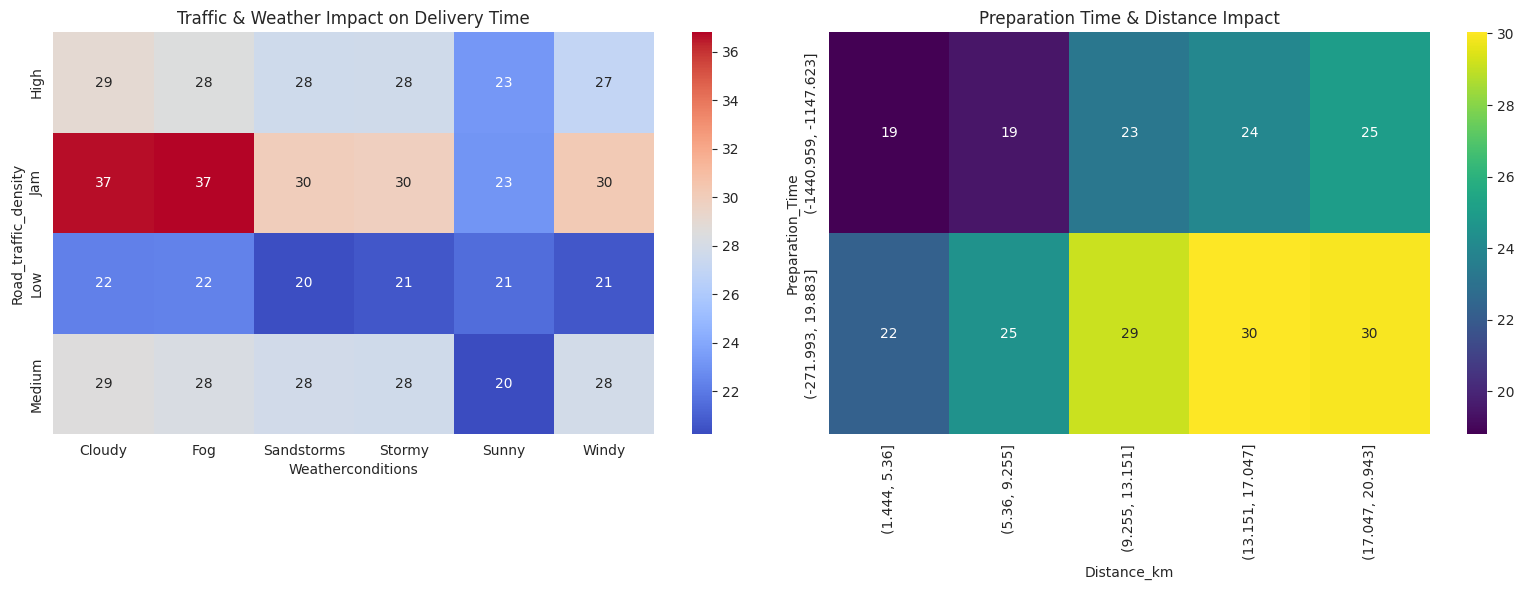

In [47]:
pivot1 = pd.pivot_table(df,
                        values='Time_taken(min)',
                        index='Road_traffic_density',
                        columns='Weatherconditions',
                        aggfunc='mean')

pivot1.columns = pivot1.columns.str.replace('conditions ', '')

pivot2 = pd.pivot_table(df,
                        values='Time_taken(min)',
                        index=pd.cut(df['Preparation_Time'], bins=5),
                        columns=pd.cut(df['Distance_km'], bins=5),
                        aggfunc='mean')

fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.heatmap(pivot1, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title("Traffic & Weather Impact on Delivery Time")

sns.heatmap(pivot2, annot=True, cmap='viridis', ax=axes[1])
axes[1].set_title("Preparation Time & Distance Impact")

plt.tight_layout()
plt.show()

Pivot Heatmap Analysis – Delivery Time Influencers

Two heatmaps were used to analyze the combined impact of multiple factors on delivery time.

1. Traffic & Weather Impact
* Delivery time is highest during traffic jams, especially under Cloudy and Fog conditions (~37 min).
* Low traffic consistently results in the lowest delivery time (~20–22 min).
Sunny weather shows relatively lower delivery time across all traffic levels.

Insight: Traffic has the strongest impact, while poor weather further increases delays.

2. Preparation Time & Distance Impact
* Delivery time increases as both distance and preparation time increase.
* Short distance + low preparation time → fastest deliveries (~19 min)
* Long distance + high preparation time → slowest deliveries (~30 min)

Insight: Distance and preparation time together significantly affect delivery performance.


Delivery time is influenced by a combination of operational (preparation), environmental (weather), and logistical (traffic & distance) factors, with the worst delays occurring when multiple unfavorable conditions occur together.

Correlation Analysis

Correlation analysis is used to measure the strength and direction of the relationship between numerical variables in a dataset. It helps to identify how one variable changes with respect to another. The correlation values range from -1 to +1, where +1 indicates a strong positive relationship, -1 indicates a strong negative relationship, and 0 indicates no relationship.

In this project, correlation analysis is performed to examine the relationships between numerical features such as delivery time, delivery person ratings, and other relevant variables. This helps in identifying key factors that influence delivery performance and supports better decision-making.

 Correlation with numerical variables

In [48]:
df.corr(numeric_only=True)

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken(min),Preparation_Time,Distance_km,Order_Hour
Delivery_person_Age,1.000000,-0.118094,0.004981,0.009663,0.004971,0.009650,-0.003657,0.115967,0.302415,0.000748,-0.001384,0.001044
Delivery_person_Ratings,-0.118094,1.000000,-0.004485,0.002539,-0.005211,0.001402,0.048483,-0.122845,-0.361422,0.004736,-0.108317,-0.061124
Restaurant_latitude,0.004981,-0.004485,1.000000,0.003675,0.999978,0.004156,0.003235,0.008900,0.012341,0.005045,0.018701,0.010903
Restaurant_longitude,0.009663,0.002539,0.003675,1.000000,0.003677,0.999945,0.002186,0.009822,0.009132,0.004904,-0.000146,0.001204
Delivery_location_latitude,0.004971,-0.005211,0.999978,0.003677,1.000000,0.004229,0.003292,0.009712,0.014493,0.004688,0.025406,0.014730
Delivery_location_longitude,0.009650,0.001402,0.004156,0.999945,0.004229,1.000000,0.002277,0.011095,0.012501,0.004349,0.010340,0.007189
Vehicle_condition,-0.003657,0.048483,0.003235,0.002186,0.003292,0.002277,1.000000,-0.103188,-0.242753,0.011824,0.008614,0.003025
multiple_deliveries,0.115967,-0.122845,0.008900,0.009822,0.009712,0.011095,-0.103188,1.000000,0.378697,0.022186,0.121235,0.065413
Time_taken(min),0.302415,-0.361422,0.012341,0.009132,0.014493,0.012501,-0.242753,0.378697,1.000000,0.056672,0.321260,0.186558
Preparation_Time,0.000748,0.004736,0.005045,0.004904,0.004688,0.004349,0.011824,0.022186,0.056672,1.000000,-0.053134,-0.155108


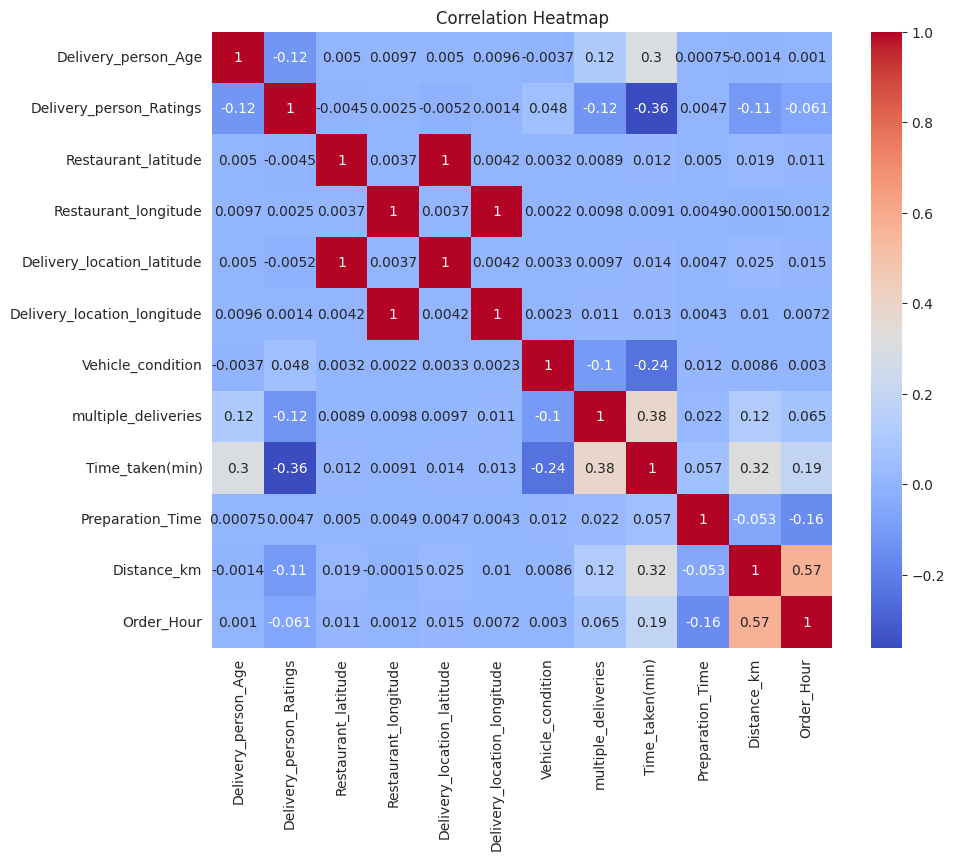

In [49]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Correlation Analysis – Heatmap

To understand the relationships between numerical variables in the dataset, a correlation heatmap was generated using Pearson correlation coefficients. This visualization helps identify the strength and direction of linear relationships between variables.

Observations
* The variable Time_taken (min) shows:
  * A moderate positive correlation with multiple_deliveries (~0.38), indicating that more deliveries lead to longer delivery times.
  * A moderate negative correlation with Delivery_person_Ratings (~ -0.36), suggesting that higher-rated delivery personnel tend to deliver faster.
  * A positive correlation with Delivery_person_Age (~0.30), indicating a slight increase in delivery time with age.
  * A negative correlation with Vehicle_condition (~ -0.24), implying that better vehicle conditions may reduce delivery time.
* Preparation_Time shows a weak positive correlation with delivery time, indicating a slight influence on total delivery duration.
* Location-related features (latitude and longitude) show very low or negligible correlation with delivery time, suggesting that raw coordinates alone do not directly explain delivery duration without transformation (e.g., distance).

Insights
* Multiple deliveries and delivery personnel ratings are among the most influential factors affecting delivery time.
* Better-rated delivery agents tend to perform more efficiently.
Vehicle condition plays a role in delivery performance, though less significant compared to delivery load.
* Derived features like distance (if included) would likely show stronger correlations than raw location coordinates.
* Most variables show weak correlations, indicating that delivery time is influenced by a combination of multiple factors rather than a single dominant variable.

The correlation analysis highlights key factors influencing delivery time, particularly multiple deliveries, delivery personnel ratings, and vehicle condition. While individual correlations are moderate, the overall pattern suggests that delivery performance is multi-dimensional and depends on operational, human, and environmental factors. Further analysis using derived features and multivariate techniques can provide deeper insights.



 Correlation with delivery time

 Correlation analysis with delivery time is performed to identify how various numerical features are related to the time taken for delivery. This analysis focuses on measuring the strength and direction of relationships between delivery time and other variables such as delivery person ratings and relevant numerical factors

In [50]:
corr_matrix = df.corr(numeric_only=True)
corr_target = corr_matrix['Time_taken(min)']
corr_target.to_frame(name='Correlation_with_Time')

,Correlation_with_Time
Delivery_person_Age,0.302415
Delivery_person_Ratings,-0.361422
Restaurant_latitude,0.012341
Restaurant_longitude,0.009132
Delivery_location_latitude,0.014493
Delivery_location_longitude,0.012501
Vehicle_condition,-0.242753
multiple_deliveries,0.378697
Time_taken(min),1.000000
Preparation_Time,0.056672


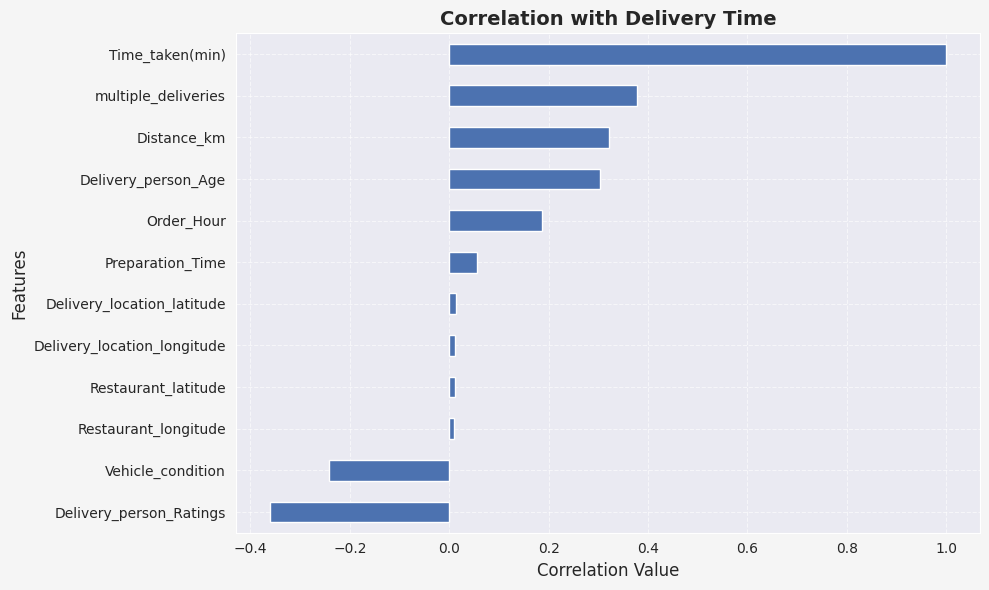

In [51]:
sns.set_style("darkgrid")

corr = df.corr(numeric_only=True)
corr_target = corr['Time_taken(min)'].sort_values()

plt.figure(figsize=(10,6), facecolor='#f5f5f5')
ax = corr_target.plot(kind='barh', color='#4C72B0')
ax.set_facecolor('#eaeaf2')

plt.title("Correlation with Delivery Time", fontsize=14, fontweight='bold')
plt.xlabel("Correlation Value", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Correlation with Delivery Time – Analysis

To identify the most influential factors affecting delivery performance, a correlation analysis was conducted between all numerical variables and Time_taken (min). The results were visualized using a horizontal bar chart for better interpretability.

* Multiple Deliveries shows the highest positive correlation (~0.38), indicating that handling more orders increases delivery time.
* Distance (km) also has a strong positive correlation, confirming that longer distances lead to longer delivery durations.
* Delivery Person Age has a moderate positive correlation (~0.30), suggesting a slight increase in delivery time with age.
* Order Hour shows a mild positive correlation, indicating that delivery time increases during certain hours (likely peak periods).
* Delivery Person Ratings has a negative correlation (~ -0.36), meaning higher-rated agents tend to deliver faster.
* Vehicle Condition also shows a slight negative correlation, indicating better vehicles may improve efficiency.
* Other features such as latitude and longitude show negligible correlation, meaning they do not directly influence delivery time.

Insights
* Delivery time is strongly influenced by operational factors like number of deliveries and distance.
* Human factors such as ratings also play an important role in efficiency.
Temporal factors (order hour) contribute to delays during peak times.
* Raw location coordinates are not meaningful unless transformed (e.g., into distance).
bold text
The analysis highlights that delivery time is influenced by a combination of factors, with multiple deliveries, distance, and delivery ratings being the most significant. Understanding these relationships can help optimize delivery operations and improve efficiency.

-----

# **Project Summary**

This Exploratory Data Analysis (EDA) project focuses on understanding the factors that influence food delivery time. The dataset contains various features such as delivery partner details, order characteristics, distance, weather conditions, and traffic levels.

During the analysis, data preprocessing steps were performed, including handling missing values, correcting data types, and creating derived columns to improve insights. Both univariate and bivariate analyses were conducted using visualizations like histograms, bar charts, line plots, and heatmaps.

Key variables such as distance, traffic density, weather conditions, and order time were explored in detail to understand their relationship with delivery time. Correlation analysis helped identify which numerical features have a strong or weak relationship with delivery duration.

The project also included pivot tables and heatmaps to visualize how delivery time varies across different categories such as city, traffic conditions, and delivery partner ratings.

# **Key Findings from Insights**

From the EDA, the following major findings were observed:

* Distance vs Delivery Time
  * Strong positive relationship
  * As distance increases, delivery time also increases significantly
* Traffic Impact
  * High traffic → longer delivery time
  * Low traffic → faster deliveries
  * Traffic is one of the most critical external factors
* Weather Conditions
  * Rainy/stormy weather increases delivery delays
  * Clear weather results in more consistent delivery times
* Time of Order
  * Peak hours (lunch/dinner) show higher delivery times
  * Non-peak hours are relatively faster
* Delivery Partner Performance
  * Higher-rated or experienced partners tend to deliver faster
  * But impact is smaller compared to distance & traffic

# **Based on these insights, the following implementations can be done:**

1. **Build a Prediction Model**

* Use features like:
  * Distance
  * Traffic condition
  * Weather
  * Order time

* Train ML models (Linear Regression, Random Forest)
* Predict accurate delivery time for new orders

2. **Route Optimization**
* Avoid high-traffic routes
* Suggest faster alternative paths
* Reduce delivery delays

3. **Smart Time Estimation for Customers**
* Show realistic delivery time instead of fixed estimates
* Improve customer trust and satisfaction

4. **Delivery Partner Allocation**
* Assign experienced partners for:
  * Long-distance orders
  * Peak hours
* Improve efficiency

5. **Dynamic Adjustments**
* Increase delivery time estimates during:
  * Bad weather
  * Heavy traffic
* Reduce complaints

**Conclusion**
--

From the analysis, several important insights were identified:

* Distance is the most influential factor affecting delivery time, with longer distances leading to higher delivery durations.
* Traffic conditions significantly impact delivery speed, with high traffic causing noticeable delays.
* Weather conditions (such as rain or storms) also increase delivery time, though their impact is moderate compared to distance and traffic.
* Delivery partner ratings and experience show some influence, indicating that more experienced partners tend to deliver faster.
* Peak hours result in longer delivery times due to increased demand and congestion.

Additionally, data preprocessing steps such as handling missing values, removing duplicates, and creating derived features like Preparation Time, Distance, and Order Hour helped improve the quality of analysis and uncover deeper insights.

Overall, the analysis shows that external factors (distance, traffic, and weather) play a more significant role than internal factors in determining delivery time.

These insights can be used to:

* Improve delivery time prediction models
* Optimize delivery routes
* Enhance customer satisfaction through accurate delivery estimates

In conclusion, delivery time can be effectively analyzed and predicted by considering key influencing factors, making the system more efficient and reliable.

------
------